In [1]:
# The purpose of this notebook is that you need to join together all the files, 
# and then normalise them, and get them into a format that matches the format that Clara had for them 

In [1]:
import numpy as np
import xarray as xr    
import glob
import pandas as pd
import itertools
import sklearn

import matplotlib.pyplot as plt
from functions import load_test_data_whole_sim, load_model_nn, load_normalisation_metrics, regression_analysis, load_results_nn

# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

In [2]:
# Set all the filepaths that will be required 
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'
data_out_fp = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

In [3]:
this_collection = 'OPM026_OPM0263_OPM031_Christoph'

In [4]:
collections = this_collection.split('_')
print(collections)

['OPM026', 'OPM0263', 'OPM031', 'Christoph']


In [5]:
filepaths = []
for i in range(len(collections)):
    if collections[i] == 'Christoph':
        collections[i] = 'Christoph_v2'
    filepaths.append(data_out_fp + collections[i] + '_' + 'whole_dataset' + '_' + 'not_yet_normalised.csv')
filepaths

['/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_whole_dataset_not_yet_normalised.csv',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM031_whole_dataset_not_yet_normalised.csv',
 '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/Christoph_v2_whole_dataset_not_yet_normalised.csv']

In [6]:
df_0_sin = pd.read_csv(filepaths[0], nrows = 11325)
print('Loaded 0')
df_1_sin = pd.read_csv(filepaths[1], nrows = 16336)
print('Loaded 1')
df_2_sin = pd.read_csv(filepaths[2], nrows = 11325)
print('Loaded 2')
df_3_sin = pd.read_csv(filepaths[3], nrows = 11338)
print('Loaded 3')

Loaded 0
Loaded 1
Loaded 2
Loaded 3


In [7]:
df_0 = pd.read_csv(filepaths[0])
print('Loaded 0')
df_1 = pd.read_csv(filepaths[1])
print('Loaded 1')
df_2 = pd.read_csv(filepaths[2])
print('Loaded 2')
df_3 = pd.read_csv(filepaths[3])
print('Loaded 3')

Loaded 0
Loaded 1
Loaded 2
Loaded 3


In [8]:
np.min(df_0.melt_m_ice_per_y)

-0.0033858877

In [9]:
np.min(df_0.melt_m_ice_per_y), np.min(df_1.melt_m_ice_per_y) ,\
np.min(df_2.melt_m_ice_per_y) , np.max(df_3.melt_m_ice_per_y) 

(-0.0033858877, -0.0031741064, -0.01439302, 0.0052771717309951)

In [10]:
np.min(df_0.melt_m_ice_per_y) * (24*60*60*365.25)/917, np.min(df_1.melt_m_ice_per_y) * (24*60*60*365.25)/917,\
np.min(df_2.melt_m_ice_per_y) * (24*60*60*365.25)/917, np.max(df_3.melt_m_ice_per_y) * (24*60*60*365.25)/917

(-116.52179899838605,
 -109.23356611629225,
 -495.32079384078514,
 181.60836926723115)

In [11]:
np.std(df_0.melt_m_ice_per_y) * (24*60*60*365.25)/917, np.std(df_1.melt_m_ice_per_y) * (24*60*60*365.25)/917,\
np.std(df_2.melt_m_ice_per_y) * (24*60*60*365.25)/917, np.std(df_3.melt_m_ice_per_y) * (24*60*60*365.25)/917

(4.493827517849566, 3.235013983896218, 18.332197191673178, 7.306792137021655)

## **To look at the distribution of variables on a basin by basin basis**

In [12]:
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [13]:
# What do we want to show?
# We want to show that the difference between reference and predicted melt is correlated to 
# whether that data point falls into the training data set or not


In [14]:
# Firstly, we should import the applied dataset, and then calculate the difference between the reference and predicted melt 

In [15]:


df_26 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

Loaded


In [ ]:
df_Ch = \
    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

In [ ]:
# And we should also import the training dataset
# then we can look at whether data is in the range of the training data or not
#df_0 = pd.read_csv(filepaths[0])
#print('Loaded 0')

In [ ]:
# And then it turns out we also need the target dataset to get the variable values for that...
#df_2 = pd.read_csv(filepaths[2])
#print('Loaded 2')

In [ ]:
# And then it turns out we also need the target dataset to get the variable values for that...
#df_3 = pd.read_csv(filepaths[3])
#print('Loaded 3')

In [ ]:
i = 17
df_results = df_Ch
mask_results = np.in1d(df_results.basin, regions[i])
df_basin = df_results[mask_results]
df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12

In [ ]:
sals = np.linspace(28,35.1,28)
temps = np.linspace(-3,8,44)
sals, temps = np.meshgrid(sals, temps)
rmse = np.zeros(sals.shape)
counts_d2 = np.zeros(sals.shape)
df_results = df_26
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_2.salinity_prop > sals[i,j]) & (df_2.salinity_prop < sals[i,j] + 0.25) & \
        (df_2.temperature_prop > temps[i,j]) & (df_2.temperature_prop < temps[i,j] + 0.25)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)
#im = plt.scatter(sals, temps, c = rmse)

counts = np.zeros(sals.shape)
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_0.salinity_prop > sals[i,j]) & (df_0.salinity_prop < sals[i,j] + 0.25) & \
        (df_0.temperature_prop > temps[i,j]) & (df_0.temperature_prop < temps[i,j] + 0.25)
    counts[i,j] = np.sum(mask)
counts1 = counts.copy()
counts1[counts1 == 0] = np.nan
counts1[counts1 > 0] = 1
counts2 = counts.copy()
counts2[counts2 == 0] = np.nan

counts_Ch = np.zeros(sals.shape)
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_3.salinity_prop > sals[i,j]) & (df_3.salinity_prop < sals[i,j] + 0.25) & \
        (df_3.temperature_prop > temps[i,j]) & (df_3.temperature_prop < temps[i,j] + 0.25)
    counts_Ch[i,j] = np.sum(mask)
counts1_Ch = counts_Ch.copy()
counts1_Ch[counts1_Ch == 0] = np.nan
counts1_Ch[counts1_Ch > 0] = 1
counts2_Ch = counts_Ch.copy()
counts2_Ch[counts2_Ch == 0] = np.nan

In [ ]:
df_applied = df_2

In [ ]:
plot_all = False
if plot_all == True:

    with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
        for i in range(18):
            fig, axs = plt.subplots(1,3, figsize = (18,5), width_ratios = (6,6,5))
            fig.subplots_adjust(wspace=0.2, hspace = 0.7)
            calls = 'df_26','df_Ch'
            for jj in range(len(calls)):
                if calls[jj] == 'df_26':
                    df_results = df_26
                elif calls[jj] == 'df_Ch':
                    df_results = df_Ch
                mask_results = np.in1d(df_results.basin, regions[i])
                df_basin = df_results[mask_results]
                df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
                # Get the mean input variables from the applied to dataset 
                mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
                df_basin_ap = df_applied[mask_applied]
                df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
                #plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
                #plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
                if calls[jj] == 'df_26':
                    diff = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
                elif calls[jj] == 'df_Ch':
                    diff = np.abs(-df_basinym.melt_Gt_per_y - df_basinym.melt_pred_Gt)
                
                im = axs[jj].scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                                 c = diff, zorder = 10)
                print(im.get_clim())
                print(np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
                im.set_clim(0,np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
                if jj == 0:
                    plt.colorbar(im, ax = axs[jj], label = 'Error in integrated melt (Gt/yr)', pad = 0.01, location = 'right')
                #ax[jj].scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
                axs[jj].set_ylim(-3,3)
                axs[jj].set_xlabel('Absolute salinity (g/kg)')
                axs[jj].set_ylabel('Conservative temperature ($^{{\\circ}}$C)')
            im = axs[0].pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
            im.set_clim(2,None)
            im = axs[1].pcolor(sals, temps, np.log10(counts2_Ch), cmap = 'Reds', alpha = 1)
            im.set_clim(2, None)
            cbar = plt.colorbar(im, ax = axs[1], location = 'left', label = 'Training data density', pad = 0.01)
            cbar.set_ticks((2,3,4,5,6))
            cbar.set_ticklabels(('10$^2$','10$^3$','10$^4$', '10$^5$', '10$^6$'))
            axs[1].yaxis.set_label_position("right")
            axs[1].yaxis.tick_right()
            labels = 'Trained on REF', 'Trained on MIDHOT'
            plt_labels = 'a)', 'b)', 'c)'
            for jj in range(2):
                axs[jj].annotate(labels[jj], xy = (0,0), xytext = (0.02,0.98), xycoords = 'axes fraction', va = 'top', ha = 'left')
            for j in range(3):    
                axs[jj].annotate(plt_labels[jj], xy = (0,0), xytext = (0.02,1.02), \
                                xycoords = 'axes fraction', va = 'bottom', ha = 'left', fontweight = 'normal')
            #ax[1].scatter(df_1.salinity_prop, df_1.temperature_prop, s = 0.1, alpha = 0.2, zorder = 3, color = 'peachpuff')
        
            ax = axs[2]
            for jj in range(len(calls)):
                if calls[jj] == 'df_26':
                    df_results = df_26
                elif calls[jj] == 'df_Ch':
                    df_results = df_Ch
                mask_results = np.in1d(df_results.basin, regions[i])
                df_basin = df_results[mask_results]
                df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
                if calls[jj] == 'df_26':
                    ax.plot(df_basinym.year*12, -df_basinym.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
                    ax.plot(df_basinym.year*12, -df_basinym.melt_pred_Gt, color = 'C9', label = 'Trained on REF')
                elif calls[jj] == 'df_Ch':
                    ax.plot(df_basinym.year*12, df_basinym.melt_pred_Gt, color = 'peachpuff', label = 'Trained on MIDHOT')
            ax.set_xlabel('Year')
            ax.set_ylabel('Integrated melt (Gt/yr)')
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            ax.legend(loc = 2, fontsize = 10)
            
    #        plt.show()
            fig.savefig('In_training_range_{}.png'.format(str(i).zfill(2)), dpi = 200, bbox_inches = 'tight')

In [ ]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,3, figsize = (18,5), width_ratios = (6,6,5))
    fig.subplots_adjust(wspace=0.2, hspace = 0.7)
    i = 17 #6,10,12,14,17 but 13 and 5
    calls = 'df_26','df_Ch'
    for jj in range(len(calls)):
        if calls[jj] == 'df_26':
            df_results = df_26
        elif calls[jj] == 'df_Ch':
            df_results = df_Ch
        mask_results = np.in1d(df_results.basin, regions[i])
        df_basin = df_results[mask_results]
        df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
        # Get the mean input variables from the applied to dataset 
        mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
        df_basin_ap = df_applied[mask_applied]
        df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
        #plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
        #plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
        if calls[jj] == 'df_26':
            diff = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
        elif calls[jj] == 'df_Ch':
            diff = np.abs(-df_basinym.melt_Gt_per_y - df_basinym.melt_pred_Gt)
        
        im = axs[jj].scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                         c = diff, zorder = 10)
        print(im.get_clim())
        print(np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
        im.set_clim(0,np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
        if jj == 0:
            plt.colorbar(im, ax = axs[jj], label = 'Error in integrated melt (Gt/yr)', pad = 0.01, location = 'right')
        #ax[jj].scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
        axs[jj].set_ylim(-3,3)
        axs[jj].set_xlabel('Absolute salinity (g/kg)')
        axs[jj].set_ylabel('Conservative temperature ($^{{\\circ}}$C)')
    im = axs[0].pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
    im.set_clim(2,None)
    im = axs[1].pcolor(sals, temps, np.log10(counts2_Ch), cmap = 'Reds', alpha = 1)
    im.set_clim(2, None)
    cbar = plt.colorbar(im, ax = axs[1], location = 'left', label = 'Training data density', pad = 0.01)
    cbar.set_ticks((2,3,4,5,6))
    cbar.set_ticklabels(('10$^2$','10$^3$','10$^4$', '10$^5$', '10$^6$'))
    axs[1].yaxis.set_label_position("right")
    axs[1].yaxis.tick_right()
    labels = 'Trained on REF', 'Trained on MIDHOT'
    plt_labels = 'a)', 'b)', 'c)'
    for jj in range(2):
        axs[jj].annotate(labels[jj], xy = (0,0), xytext = (0.02,0.98), xycoords = 'axes fraction', va = 'top', ha = 'left')
    for jj in range(3):    
        axs[jj].annotate(plt_labels[jj], xy = (0,0), xytext = (0.02,1.02), \
                        xycoords = 'axes fraction', va = 'bottom', ha = 'left', fontweight = 'normal')
    #ax[1].scatter(df_1.salinity_prop, df_1.temperature_prop, s = 0.1, alpha = 0.2, zorder = 3, color = 'peachpuff')

    ax = axs[2]
    for jj in range(len(calls)):
        if calls[jj] == 'df_26':
            df_results = df_26
        elif calls[jj] == 'df_Ch':
            df_results = df_Ch
        mask_results = np.in1d(df_results.basin, regions[i])
        df_basin = df_results[mask_results]
        df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
        if calls[jj] == 'df_26':
            ax.plot(df_basinym.year*12, -df_basinym.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
            ax.plot(df_basinym.year*12, -df_basinym.melt_pred_Gt, color = 'C9', label = 'Trained on REF')
        elif calls[jj] == 'df_Ch':
            ax.plot(df_basinym.year*12, df_basinym.melt_pred_Gt, color = 'peachpuff', label = 'Trained on MIDHOT')
    ax.set_xlabel('Year')
    ax.set_ylabel('Integrated melt (Gt/yr)')
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.legend(loc = 2, fontsize = 10)
    
    plt.show()
    fig.savefig('In_training_range_{}.png'.format(str(i).zfill(2)), dpi = 200, bbox_inches = 'tight')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
i = 17
mask_results = np.in1d(df_results.basin, regions[i])
df_basin = df_results[mask_results]
df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
# Get the mean input variables from the applied to dataset 
mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
df_basin_ap = df_applied[mask_applied]
df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
#plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
#plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
im = plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                 c = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt), zorder = 10, s = 1)
#print(np.min(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt), np.max(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
im.set_clim(0,500)
plt.colorbar(im)
#ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
im = ax.pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
im.set_clim(2,None)
ax.set_ylim(-3,3)
ax.set_xlim(29,35)
plt.show()


In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
df_results = df_26
for i in range(18):
    mask_results = np.in1d(df_results.basin, regions[i])
    df_basin = df_results[mask_results]
    df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
    # Get the mean input variables from the applied to dataset 
    mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
    df_basin_ap = df_applied[mask_applied]
    df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
#plt.scatter(df_basin_ap.salinity_prop, df_basin_ap.temperature_prop, c = df_basin_ap.year + df_basin_ap.month/12)
#plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, c = df_apym.year)
    #im = plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
    #                 c = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt), zorder = 10, s = 1)
    error_Gt = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
    max_error_Gt = max(error_Gt)
    min_error_Gt = min(error_Gt)
    print(max_error_Gt, min_error_Gt)
    im = plt.scatter(df_apym.salinity_prop, df_apym.temperature_prop, \
                     c = error_Gt, zorder = 10, s = 1)
    im.set_clim(0,500)
plt.colorbar(im)
#ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 1, color = 'C9')
im = ax.pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
im.set_clim(2,None)
ax.set_ylim(-3,3)
ax.set_xlim(29,35)
plt.show()


In [ ]:
df_results = df_26
df_applied = df_2
# Get the results of applying to the basin
mask_results = np.in1d(df_results.basin, regions[i])
df_basin = df_results[mask_results]
df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
# Get the mean input variables from the applied to dataset 
mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
df_basin_ap = df_applied[mask_applied]
df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
euc = np.sqrt((df_apym.salinity_prop - df_0.salinity_prop.mean())**2 +  (df_apym.temperature_prop - df_0.temperature_prop.mean()) ** 2)

In [ ]:
fig, axs = plt.subplots(1,3, figsize = (18,5))
axs[0].plot(df_basinym.year*12 , np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))#, s = 0.1)
axs[1].plot(df_apym.year, euc)
axs[2].scatter(euc, np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
regression_analysis(euc, np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt))
plt.show()

In [ ]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
    df_results = df_26
    fig, axs = plt.subplots(1,3, figsize = (18,5))
    for i in range(18):
        mask_results = np.in1d(df_results.basin, regions[i])
        df_basin = df_results[mask_results]
        df_basinym = df_basin.groupby(['year'], as_index = False).sum()/12
        # Get the mean input variables from the applied to dataset 
        mask_applied = np.in1d(df_applied.basins_NEMO, regions[i])
        df_basin_ap = df_applied[mask_applied]
        df_apym = df_basin_ap.groupby(['year'], as_index = False).mean()
        euc = np.sqrt((df_apym.salinity_prop - df_0.salinity_prop.mean())**2 +  (df_apym.temperature_prop - df_0.temperature_prop.mean()) ** 2)
        error_Gt = np.abs(-df_basinym.melt_Gt_per_y + df_basinym.melt_pred_Gt)
        axs[0].plot(df_basinym.year*12 , error_Gt)#, s = 0.1)
        axs[1].plot(df_apym.year, euc)
        axs[2].scatter(euc, error_Gt)
    axs[0].set_ylabel('Integrated melt (Gt/yr)')
    axs[0].set_xlabel('Year')
    axs[1].set_ylabel('Distance to mean temp and salinity')
    axs[1].set_xlabel('Year')
    axs[2].set_ylabel('Integrated melt (Gt/yr)')
    axs[2].set_xlabel('Distance to mean temp and salinity')
    plt.show()

In [ ]:
eucall = np.sqrt((df_2.salinity_prop - df_0.salinity_prop.mean())**2 +  (df_2.temperature_prop - df_0.temperature_prop.mean()) ** 2)
    

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
df_results = df_26
im = ax.scatter(df_2.salinity_prop, df_2.temperature_prop, c = np.abs(df_results.melt_Gt_per_y - df_results.melt_pred_Gt), s = 0.1)
plt.colorbar(im)
im.set_clim(0,1)
ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.01, alpha = 0.2, zorder = 0, color = 'C9')
plt.show()


In [ ]:
sal = 30
temp = 2
mask = (df_2.salinity_prop > sal) & (df_2.salinity_prop < sal + 0.25) & \
        (df_2.temperature_prop > temp) & (df_2.temperature_prop < temp + 0.25)
np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))

In [ ]:
sals = np.linspace(28,35.1,28)
temps = np.linspace(-3,8,44)
sals, temps = np.meshgrid(sals, temps)
rmse = np.zeros(sals.shape)
counts_d2 = np.zeros(sals.shape)
df_results = df_26
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_2.salinity_prop > sals[i,j]) & (df_2.salinity_prop < sals[i,j] + 0.25) & \
        (df_2.temperature_prop > temps[i,j]) & (df_2.temperature_prop < temps[i,j] + 0.25)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)
#im = plt.scatter(sals, temps, c = rmse)

In [ ]:
counts = np.zeros(sals.shape)
for i,j in itertools.product(range(sals.shape[0]), range(sals.shape[1])):
    print(i*28+j, 'out of', 44*28, 'processing', end = '\r')
    mask = (df_0.salinity_prop > sals[i,j]) & (df_0.salinity_prop < sals[i,j] + 0.25) & \
        (df_0.temperature_prop > temps[i,j]) & (df_0.temperature_prop < temps[i,j] + 0.25)
    counts[i,j] = np.sum(mask)
counts1 = counts.copy()
counts1[counts1 == 0] = np.nan
counts1[counts1 > 0] = 1
counts2 = counts.copy()
counts2[counts2 == 0] = np.nan

In [ ]:
alpha_mask = (np.log10(counts_d2))/np.max(np.log10(counts_d2))
alpha_mask[alpha_mask < 0] = 0 
alpha_mask[alpha_mask > 1] = 1 

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
im = ax.scatter(sals, temps, c = rmse, alpha = alpha_mask, cmap = 'viridis_r')
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (12,5))
for i in range(1):
    im = ax[i].pcolor(sals, temps, rmse, cmap = 'Reds')
    im.set_clim(0,0.001)
plt.colorbar(im, ax = ax[0])

im = ax[1].pcolor(sals, temps, np.log10(counts2), cmap = 'Reds', alpha = 1)
im.set_clim(2, None)
plt.colorbar(im)
#im.set_clim(0.5,1.5)
plt.show()

In [ ]:
logcounts = np.log10(counts)
mask = logcounts <0
logcounts[mask] = -0.1

In [ ]:
plt.scatter(logcounts, rmse)
plt.show()

## **To assess the impact of changes in geometry**

In [7]:
df_26on263 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM0263_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

Loaded


In [11]:
df_1 = pd.read_csv(filepaths[1])
print('Loaded 1')

Loaded 1


In [8]:
df_results = df_26on263

In [12]:
isf = 100
dist = 50000
mask = (df_1.corrected_isdraft > isf) & (df_1.corrected_isdraft < isf + 100) & \
        (df_1.distances_OC > dist) & (df_1.distances_OC < dist + 10000)

In [13]:
df_results =  df_26on263
isfs = np.linspace(0,2000,20)
baths = np.linspace(0,2500,25)
isfs, baths = np.meshgrid(isfs, baths)
rmse = np.zeros(isfs.shape)
counts_d2 = np.zeros(isfs.shape)
df_results = df_26on263
for i,j in itertools.product(range(isfs.shape[0]), range(isfs.shape[1])):
    print(i*24+j, 'out of', 24*25, 'processing', end = '\r')
    mask = (df_1.corrected_isdraft > isfs[i,j]) & (df_1.corrected_isdraft < isfs[i,j] + 100) & \
        (df_1.bathymetry > baths[i,j]) & (df_1.bathymetry < baths[i,j] + 100)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)

TypeError: Incompatible X, Y inputs to pcolor; see help(pcolor)

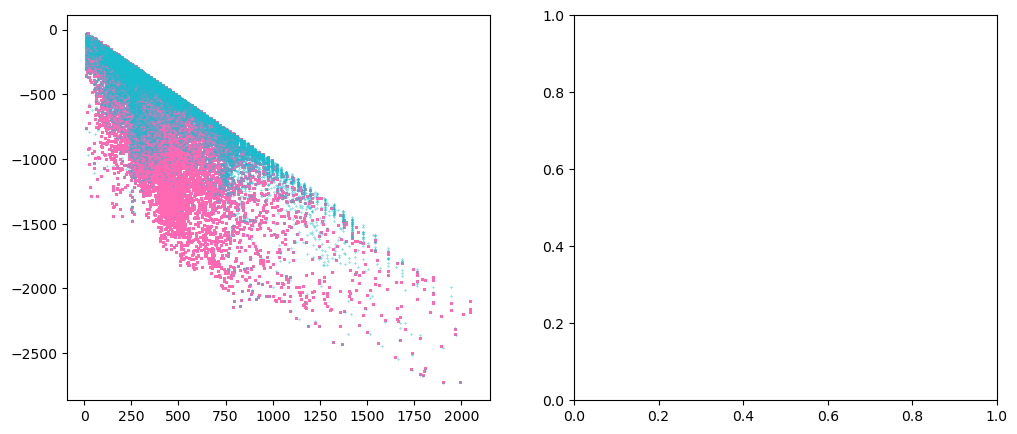

In [16]:
fig, axs = plt.subplots(1,2, figsize = (12,5))
axs[0].scatter(df_1.corrected_isdraft, -df_1.bathymetry, s = 0.1, color = 'hotpink', marker = 'o')
axs[0].scatter(df_0_sin.corrected_isdraft, -df_0_sin.bathymetry, s = 0.1, color = 'C9')
#axs[0].pcolor(isfs+50, dists+500, rmse, cmap = 'Reds', zorder = 0)
im = axs[0].pcolor(isfs+10, -baths-12.5, rmse, cmap = 'Reds', zorder = 0)
im.set_clim(0,0.0003)
im = axs[1].pcolor(isfs+10, -baths-12.5, rmse, cmap = 'Reds', zorder = 0)
im.set_clim(0,0.0003)
plt.colorbar(im)
ylims = axs[0].get_ylim()
axs[1].set_ylim(ylims)

In [15]:
df_results =  df_26on263
isfs = np.linspace(0,2000,21)
dists = np.linspace(0,150000,31)
isfs, dists = np.meshgrid(isfs, dists)
rmse_isGL = np.zeros(isfs.shape)
counts_d2 = np.zeros(isfs.shape)
df_results = df_26on263
for i,j in itertools.product(range(isfs.shape[0]), range(isfs.shape[1])):
    print(i*21+j, 'out of', 21*31, 'processing', end = '\r')
    mask = (df_1.corrected_isdraft > isfs[i,j]) & (df_1.corrected_isdraft < isfs[i,j] + 100) & \
        (df_1.distances_GL > dists[i,j]) & (df_1.distances_GL < dists[i,j] + 10000)
    rmse_isGL[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)

/tmp/ipykernel_2920103/1644810018.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im, ax = axs[1], pad = 0.1, label = 'RMSE (m/s)')


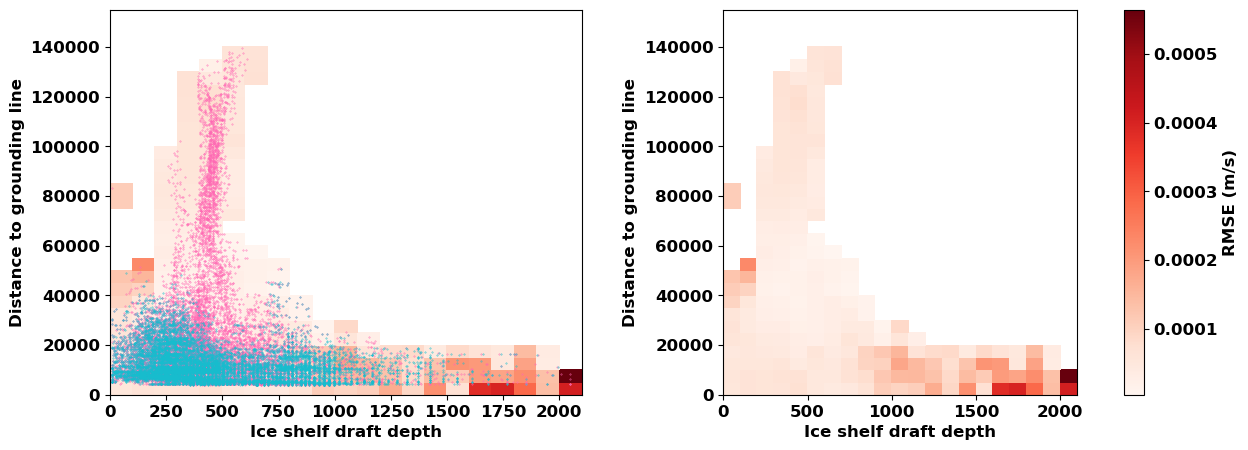

In [17]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,2, figsize = (14,5))
    plt.subplots_adjust(wspace = 0.3)
    axs[0].scatter(df_1_sin.corrected_isdraft, df_1_sin.distances_GL, s = 0.1, color = 'hotpink')
    axs[0].scatter(df_0_sin.corrected_isdraft, df_0_sin.distances_GL, s = 0.1, color = 'C9')
    axs[0].pcolor(isfs+50, dists+2500, rmse_isGL, cmap = 'Reds', zorder = 0)
    im = axs[1].pcolor(isfs+50, dists+2500, rmse_isGL, cmap = 'Reds', zorder = 0)
    for i in range(2):
        axs[i].set_xlabel('Ice shelf draft depth')
        axs[i].set_ylabel('Distance to grounding line')
    plt.colorbar(im, ax = axs[1], pad = 0.1, label = 'RMSE (m/s)')
    #axs[0].yaxis.tick_right()
    #axs[0].set_yticklabels(('','','','','','','',''))
    axs[0].set_ylabel('Distance to grounding line')
   
    plt.show()

In [18]:
df_results =  df_26on263
isfs = np.linspace(0,2000,21)
dists = np.linspace(0,750000,31)
isfs, dists = np.meshgrid(isfs, dists)
rmse = np.zeros(isfs.shape)
counts_d2 = np.zeros(isfs.shape)
df_results = df_26on263
for i,j in itertools.product(range(isfs.shape[0]), range(isfs.shape[1])):
    print(i*21+j, 'out of', 21*31, 'processing', end = '\r')
    mask = (df_1.corrected_isdraft > isfs[i,j]) & (df_1.corrected_isdraft < isfs[i,j] + 100) & \
        (df_1.distances_OO > dists[i,j]) & (df_1.distances_OO < dists[i,j] + 10000)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)

In [ ]:
150000/30

/tmp/ipykernel_2920103/1015841329.py:11: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im, ax = axs[1], pad = 0.1, label = 'RMSE (m/s)')


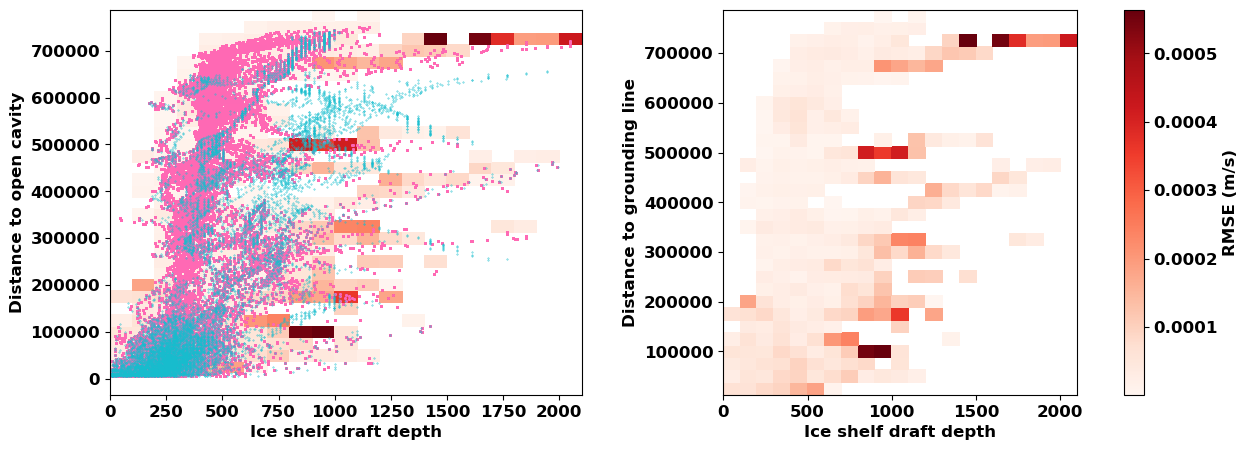

In [19]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,2, figsize = (14,5))
    plt.subplots_adjust(wspace = 0.3)
    axs[0].scatter(df_1.corrected_isdraft, df_1.distances_OO, s = 0.1, color = 'hotpink')
    axs[0].scatter(df_0_sin.corrected_isdraft, df_0_sin.distances_OO, s = 0.1, color = 'C9')
    axs[0].pcolor(isfs+50, dists+25000, rmse, cmap = 'Reds', zorder = 0)
    im = axs[1].pcolor(isfs+50, dists+25000, rmse, cmap = 'Reds', zorder = 0)
    for i in range(2):
        axs[i].set_xlabel('Ice shelf draft depth')
        axs[i].set_ylabel('Distance to grounding line')
    plt.colorbar(im, ax = axs[1], pad = 0.1, label = 'RMSE (m/s)')
    #axs[0].yaxis.tick_right()
    #axs[0].set_yticklabels(('','','','','','','',''))
    axs[0].set_ylabel('Distance to open cavity')
   
    plt.show()

In [20]:
df_results =  df_26on263
dists = np.linspace(0,250000,25)
dists1, dists2 = np.meshgrid(dists, dists)
rmse = np.zeros(dists1.shape)
counts_d2 = np.zeros(dists1.shape)
df_results = df_26on263
for i,j in itertools.product(range(dists1.shape[0]), range(dists1.shape[1])):
    print(i*24+j, 'out of', 24*25, 'processing', end = '\r')
    mask = (df_1.distances_GL > dists1[i,j]) & (df_1.distances_GL < dists1[i,j] + 10000) & \
        (df_1.distances_OC > dists2[i,j]) & (df_1.distances_OC < dists2[i,j] + 10000)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)

/tmp/ipykernel_2920103/2394165188.py:6: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im)


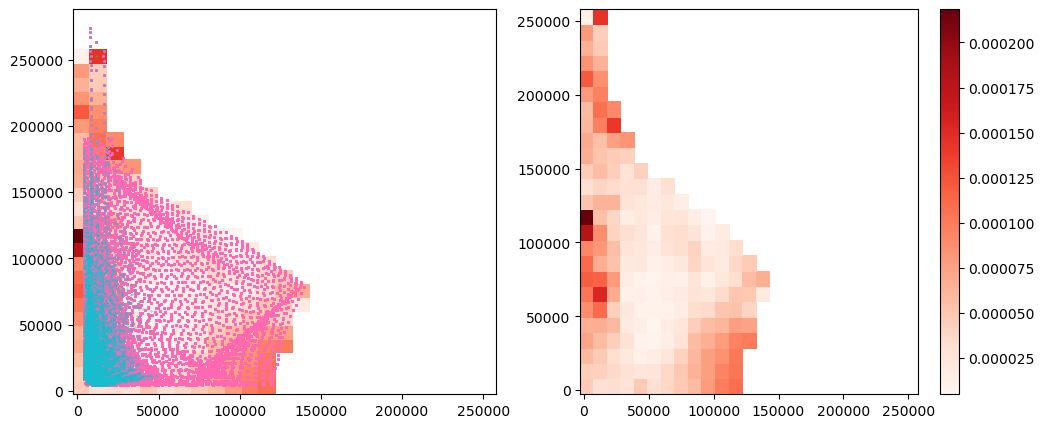

In [21]:
fig, axs = plt.subplots(1,2, figsize = (12,5))
axs[0].scatter(df_1.distances_GL, df_1.distances_OC, s = 0.1, color = 'hotpink')
axs[0].scatter(df_0_sin.distances_GL, df_0_sin.distances_OC, s = 0.1, color = 'C9')
axs[0].pcolor(dists1+2500, dists2+2500, rmse, cmap = 'Reds', zorder = 0)
im = axs[1].pcolor(dists1+2500, dists2+2500, rmse, cmap = 'Reds', zorder = 0)
plt.colorbar(im)
plt.show()

In [22]:
df_1.columns

Index(['lat', 'lon', 'temperature_prop', 'salinity_prop', 'melt_m_ice_per_y',
       'mean_T', 'mean_S', 'std_T', 'std_S', 'year', 'month', 'basins_NEMO',
       'distances_GL', 'distances_OO', 'distances_OC', 'corrected_isdraft',
       'area', 'bathymetry', 'slope_is_lon', 'slope_is_lat', 'slope_ba_lon',
       'slope_ba_lat', 'slope_is_across_front', 'slope_is_towards_front',
       'slope_ba_across_front', 'slope_ba_towards_front'],
      dtype='object')

In [23]:
0.06*2/24

0.005

In [41]:
df_results =  df_26on263
ass = np.linspace(-0.06,0.06,25)
bss = np.linspace(-0.06,0.06,25)
ass, bss = np.meshgrid(ass, bss)
rmse = np.zeros(ass.shape)
counts_d2 = np.zeros(ass.shape)
df_results = df_26on263
for i,j in itertools.product(range(ass.shape[0]), range(ass.shape[1])):
    print(i*25+j, 'out of', 25*25, 'processing', end = '\r')
    mask = (df_1.slope_is_across_front > ass[i,j]-0.0025) & (df_1.slope_is_across_front < ass[i,j] + 0.0025) & \
        (df_1.slope_is_towards_front> bss[i,j]-0.0025) & (df_1.slope_is_towards_front < bss[i,j] + 0.0025)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)

In [25]:
df_26on263_point = df_26on263.groupby(['lat','lon'], as_index = False).mean()

/tmp/ipykernel_2920103/4185341974.py:26: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(im[1], ax = axs[2], pad = 0.1, label = 'RMSE (m/s)')


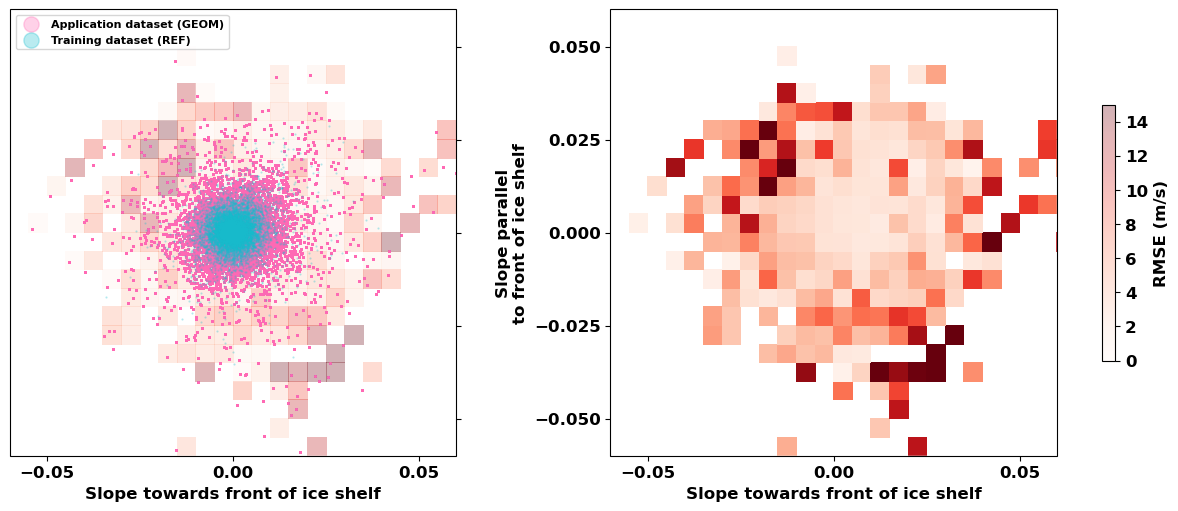

In [27]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):

    fig = plt.figure(constrained_layout=True, figsize = (12,5))
    gs = fig.add_gridspec(1,3, width_ratios = (6,5,1), wspace = -1)
    axs = [[],[],[]]
    axs[0] = fig.add_subplot(gs[0,0], projection= proj)
    axs[1] = fig.add_subplot(gs[0,1:], projection= proj)
    axs[2] = fig.add_subplot(gs[0,2], projection= proj)
    gs.update(wspace=0, hspace = 0.7)
    axs[0].scatter(df_1.slope_is_across_front, df_1.slope_is_towards_front, s = 0.3, color = 'hotpink', alpha = 0.3, \
                       label = 'Application dataset (GEOM)')
    axs[0].scatter(df_0_sin.slope_is_across_front, df_0_sin.slope_is_towards_front, s = 0.3, color = 'C9', alpha = 0.3, \
                  label = 'Training dataset (REF)')
    im = [[],[]]
    im[0] = axs[1].pcolor(ass+0.0025, bss+0.0025, rmse*(31536000/917), cmap = 'Reds', zorder = 0)
    im[1] = axs[0].pcolor(ass+0.0025, bss+0.0025, rmse*(31536000/917), cmap = 'Reds', zorder = 0, alpha =0.3)
    axs[0].legend(loc = 2, markerscale = 20, fontsize = 8)
    for i in range(2):
        axs[i].set_xlabel('Slope towards front of ice shelf')
        axs[i].set_ylabel('Slope parallel\nto front of ice shelf')
        axs[i].set_xticks((-0.05,0,0.05))
        axs[i].set_yticks((-0.05,-0.025,0,0.025, 0.05))
        axs[i].set_xlim(-0.06,0.06)
        axs[i].set_ylim(-0.06,0.06)
        im[i].set_clim(0,15)
    plt.colorbar(im[1], ax = axs[2], pad = 0.1, label = 'RMSE (m/s)')
    axs[0].yaxis.tick_right()
    axs[0].set_yticklabels(('','','','',''))
    axs[0].set_ylabel('')
    axs[2].axis('off')
    fig.savefig('FIGURES/Bigslopes.png', dpi = 200, bbox_inches = 'tight')

In [28]:
angles = np.linspace(0,360,60)
x = 0.02 * np.cos(angles*np.pi/180)
y = 0.02 * np.sin(angles*np.pi/180)
x15 = 0.015 * np.cos(angles*np.pi/180)
y15 = 0.015 * np.sin(angles*np.pi/180)

nemo_run = 'OPM026'
geom_26 = xr.load_dataset('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/'+nemo_run+'_geom_vars.nc')
mask_26 = xr.load_dataset('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/'+nemo_run+'_geometric_masks.nc')

nemo_run = 'OPM0263'
geom_263 = xr.load_dataset('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/'+nemo_run+'_geom_vars.nc')
mask_263 = xr.load_dataset('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/'+nemo_run+'_geometric_masks.nc')

In [36]:
df_1_sin_save = df_1_sin[['slope_is_across_front', 'slope_is_towards_front']]
df_0_sin_save = df_0_sin[['slope_is_across_front', 'slope_is_towards_front']]

In [37]:
df_0_sin_save.to_csv(fp_data + 'df_0_sin_save.csv')
df_1_sin_save.to_csv(fp_data + 'df_1_sin_save.csv')

In [38]:
df_0_sin_save = pd.read_csv(fp_data + 'df_0_sin_save.csv')
df_1_sin_save = pd.read_csv(fp_data + 'df_1_sin_save.csv')

In [42]:
fp_data = 'Figure_data/'
np.savetxt(fp_data + 'ass.csv', ass, delimiter = ',')
np.savetxt(fp_data + 'bss.csv', bss, delimiter = ',')
np.savetxt(fp_data + 'rmse_geom.csv', rmse, delimiter = ',')
ass = np.loadtxt(fp_data + 'rmse_geom.csv', delimiter = ',')
bss = np.loadtxt(fp_data + 'rmse_geom.csv', delimiter = ',')
rmse = np.loadtxt(fp_data + 'rmse_geom.csv', delimiter = ',')

In [40]:
x
y

array([ 0.00000000e+00,  2.12586971e-03,  4.22765247e-03,  6.28153424e-03,
        8.26424372e-03,  1.01533160e-02,  1.19273472e-02,  1.35662367e-02,
        1.50514154e-02,  1.63660555e-02,  1.74952617e-02,  1.84262396e-02,
        1.91484408e-02,  1.96536825e-02,  1.99362401e-02,  1.99929122e-02,
        1.98230566e-02,  1.94285979e-02,  1.88140053e-02,  1.79862426e-02,
        1.69546886e-02,  1.57310311e-02,  1.43291348e-02,  1.27648837e-02,
        1.10560013e-02,  9.22185003e-03,  7.28321151e-03,  5.26205128e-03,
        3.18126992e-03,  1.06444350e-03, -1.06444350e-03, -3.18126992e-03,
       -5.26205128e-03, -7.28321151e-03, -9.22185003e-03, -1.10560013e-02,
       -1.27648837e-02, -1.43291348e-02, -1.57310311e-02, -1.69546886e-02,
       -1.79862426e-02, -1.88140053e-02, -1.94285979e-02, -1.98230566e-02,
       -1.99929122e-02, -1.99362401e-02, -1.96536825e-02, -1.91484408e-02,
       -1.84262396e-02, -1.74952617e-02, -1.63660555e-02, -1.50514154e-02,
       -1.35662367e-02, -

/tmp/ipykernel_2920103/1144953423.py:27: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = plt.colorbar(im[1], ax = axs[2], pad = 0.1, label = 'RMSE (m/yr)')


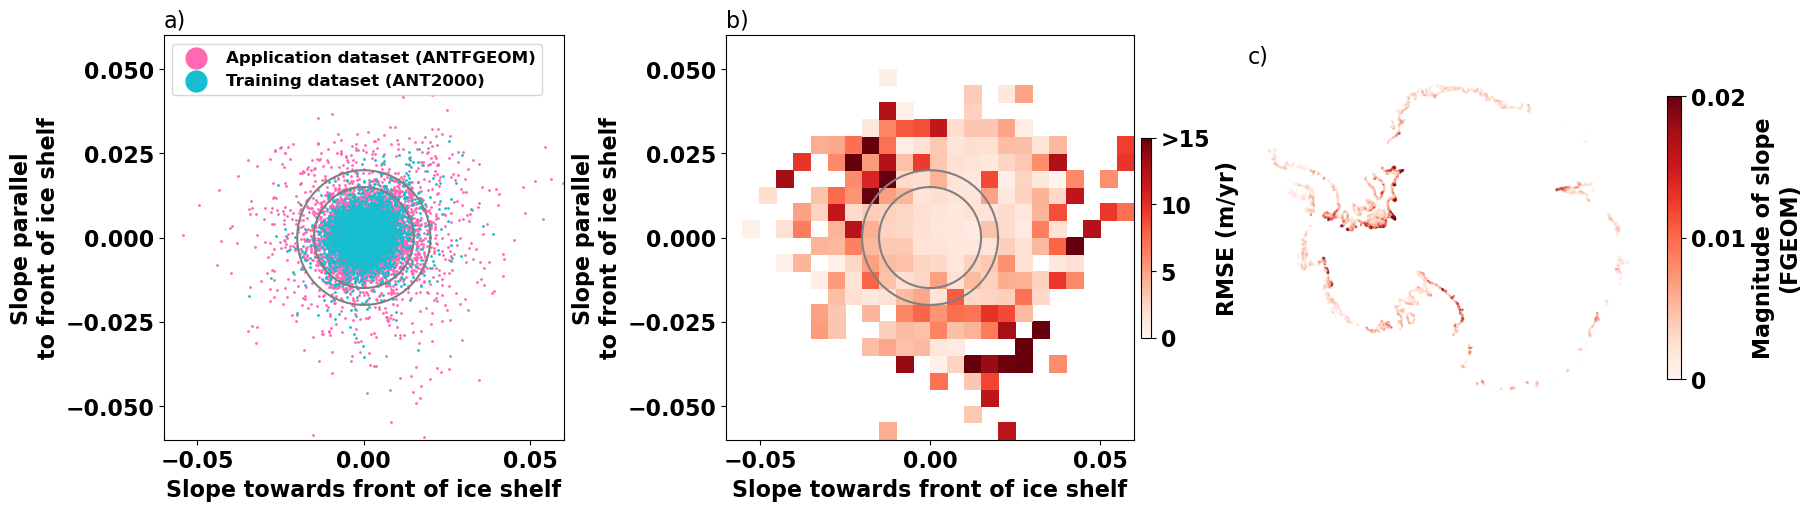

In [30]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):

    fig = plt.figure(constrained_layout=True, figsize = (18,5))
    gs = fig.add_gridspec(1,4, width_ratios = (6,5,1,6), wspace = -1)
    axs = [[],[],[],[]]
    axs[0] = fig.add_subplot(gs[0,0])
    axs[1] = fig.add_subplot(gs[0,1:3])
    axs[2] = fig.add_subplot(gs[0,2])
    axs[3] = fig.add_subplot(gs[0,3], projection = proj)
    gs.update(wspace=0, hspace = 0.7)
    axs[0].scatter(df_1_sin.slope_is_across_front, df_1_sin.slope_is_towards_front, s = 1, color = 'hotpink', alpha = 1, \
                       label = 'Application dataset (ANTFGEOM)')
    axs[0].scatter(df_0_sin.slope_is_across_front, df_0_sin.slope_is_towards_front, s = 1, color = 'C9', alpha = 1, \
                  label = 'Training dataset (ANT2000)')
    im = [[],[]]
    im[1] = axs[1].pcolor(ass+0.0025, bss+0.0025, rmse*(31536000/917), cmap = 'Reds', zorder = 0)
    axs[0].legend(loc = 2, markerscale = 15, fontsize = 12)
    for i in range(2):
        axs[i].set_xlabel('Slope towards front of ice shelf')
        axs[i].set_ylabel('Slope parallel\nto front of ice shelf')
        axs[i].set_xticks((-0.05,0,0.05))
        axs[i].set_yticks((-0.05,-0.025,0,0.025, 0.05))
        axs[i].set_xlim(-0.06,0.06)
        axs[i].set_ylim(-0.06,0.06)
    im[1].set_clim(0,15)
    cbar = plt.colorbar(im[1], ax = axs[2], pad = 0.1, label = 'RMSE (m/yr)')
    cbar.set_ticks((0,5,10,15))
    cbar.set_ticklabels(('0','5','10','>15'))
    #axs[0].yaxis.tick_right()
    #axs[0].set_yticklabels(('','','','',''))
    axs[0].set_ylabel('Slope parallel\nto front of ice shelf')
    axs[2].axis('off')
    #axs[0].plot(x,y, color = 'grey')
    axs[1].plot(x,y, color = 'grey')
    axs[0].plot(x,y, color = 'grey', label = 'Magnitude of slope = 0.02')
    axs[1].plot(x15,y15, color = 'grey')
    axs[0].plot(x15,y15, color = 'grey', label = 'Magnitude of slope = 0.015')
    
    
    im = axs[3].scatter(geom_263.lon.values[~np.isnan(mask_263.closed_cavities_nan)], \
                geom_263.lat.values[~np.isnan(mask_263.closed_cavities_nan)], \
                c = np.sqrt((geom_263.slope_is_across_front**2)+(geom_263.slope_is_towards_front**2)).values[~np.isnan(mask_263.closed_cavities_nan)], cmap = 'Reds',\
               transform = trans, s = 0.01)
    im.set_clim(0,0.02)
    #im.set_clim(0.0,None)
    cbar = plt.colorbar(im, shrink = 0.7)
    cbar.set_label('Magnitude of slope\n(FGEOM)') 
    cbar.set_ticks((0,0.01,0.02))
    cbar.set_ticklabels(('0','0.01','0.02'))
    axs[3].axis('off')

    plt_labels = 'a)', 'b)', 'c)', 'c)'
    for i in (0,1,3):
        axs[i].annotate(plt_labels[i], xy = (0,0), xytext = (0,1.02), xycoords = 'axes fraction', fontweight = 'normal')
    
    fig.savefig('FIGURES/Bigslopes.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
im = plt.scatter(df_1.slope_is_across_front, df_1.slope_is_towards_front, \
                 s = (df_26on263.melt_m_ice_per_y - df_26on263.melt_pred_mean)*(31536000/917), \
                c = (df_26on263.melt_m_ice_per_y - df_26on263.melt_pred_mean)*(31536000/917), alpha = 0.1)
plt.colorbar()
im.set_clim(1,15)

In [ ]:
ax = fig.add_subplot(gs[0,0], projection= proj)

im = ax.scatter(geom_263.lon.values[~np.isnan(mask_263.closed_cavities_nan)], \
            geom_263.lat.values[~np.isnan(mask_263.closed_cavities_nan)], \
            c = np.sqrt((geom_263.slope_is_across_front**2)+(geom_263.slope_is_towards_front**2)).values[~np.isnan(mask_263.closed_cavities_nan)], cmap = 'Reds',\
           transform = trans, s = 0.01)
im.set_clim(0,0.02)
cbar = plt.colorbar(im, shrink = 0.7)
cbar.set_label('Ice-shelf thinning (m)') 

In [ ]:
df_results =  df_26on263
ass = np.linspace(-0.08,0.08,32)
bss = np.linspace(-0.08,0.08,32)
ass, bss = np.meshgrid(ass, bss)
rmse = np.zeros(ass.shape)
counts_d2 = np.zeros(ass.shape)
df_results = df_26on263
for i,j in itertools.product(range(ass.shape[0]), range(ass.shape[1])):
    print(i*32+j, 'out of', 32*32, 'processing', end = '\r')
    mask = (df_1.slope_ba_across_front > ass[i,j]-0.0025) & (df_1.slope_ba_across_front < ass[i,j] + 0.0025) & \
        (df_1.slope_ba_towards_front> bss[i,j]-0.0025) & (df_1.slope_ba_towards_front < bss[i,j] + 0.0025)
    rmse[i,j] = np.sqrt(np.mean((df_results[mask].melt_m_ice_per_y - df_results[mask].melt_pred_mean)**2))
    counts_d2[i,j] = np.sum(mask)

In [ ]:
with plt.rc_context({'font.size': 12, 'font.weight': 'bold', 'axes.labelsize': 12, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,2, figsize = (10,5))
    fig.subplots_adjust(wspace=0.4, hspace = 0.7)
    axs[0].scatter(df_1.slope_ba_across_front, df_1.slope_ba_towards_front, s = 0.1, color = 'hotpink', alpha = 0.3, \
                   label = 'Application dataset (GEOM)')
    axs[0].scatter(df_0.slope_ba_across_front, df_0.slope_ba_towards_front, s = 0.1, color = 'C9', alpha = 0.3, \
                  label = 'Training dataset (REF)')
    im = axs[1].pcolor(ass, bss, rmse*(31536000/917), cmap = 'Reds', zorder = 0)
    aim = axs[0].pcolor(ass, bss, rmse*(31536000/917), cmap = 'Reds', zorder = 0, alpha =0.3)
    plt.colorbar(im, orientation = 'horizontal', ax = axs, shrink = 0.3, pad = 0.2, label = 'RMSE (m/yr)')
    axs[0].legend(loc = 2, markerscale = 20, fontsize = 8)
    for i in range(2):
        axs[i].set_xlabel('Slope towards front of ice shelf')
        axs[i].set_ylabel('Slope parallel\nto front of ice shelf')
        axs[i].set_xticks((-0.06,-0.03,0,0.03,0.06))
        axs[i].set_yticks((-0.06,-0.03,0,0.03, 0.06))
        axs[i].set_xlim(-0.08,0.08)
        axs[i].set_ylim(-0.08,0.08)
    plt.show()
    #fig.savefig('FIGURES/Bigslopes.png', dpi = 200, bbox_inches = 'tight')

In [ ]:


fig = plt.figure(constrained_layout=True, figsize = (12,5))
gs = fig.add_gridspec(1,2)
ax = fig.add_subplot(gs[0,0], projection= proj)

im = ax.scatter(df_26on263_point.lon, df_26on263_point.lat, \
                 c = np.abs(df_26on263_point.melt_m_ice_per_y - df_26on263_point.melt_pred_mean)* (31536000/917), \
                 cmap = 'Reds',s = 0.01, transform = trans)
im.set_clim(0,5)
cbar = plt.colorbar(im, ax = ax, shrink = 0.7)
#cbar.set_ticks((0,0.02,0.04,0.06,0.08,0.1))
#cbar.set_ticklabels((0,0.02,0.04,0.06,0.08, '>0.1'))
cbar.set_label('RMSE (m/yr)')



In [ ]:
depth_26 = (geom_26.isf_draft).values
depth_26[np.isnan(depth_26)] = np.nan
depth_26

fig = plt.figure(constrained_layout=True, figsize = (6,5))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0], projection= proj)

im = ax.scatter(geom_263.lon.values[~np.isnan(mask_263.closed_cavities_nan)], \
            geom_263.lat.values[~np.isnan(mask_263.closed_cavities_nan)], \
            c = np.abs(depth_26 - (geom_263.isf_draft)).values[~np.isnan(mask_263.closed_cavities_nan)], cmap = 'Reds',\
           transform = trans, s = 0.01)
im.set_clim(0,1000)
cbar = plt.colorbar(im, shrink = 0.7)
cbar.set_label('Ice-shelf thinning (m)') 

In [ ]:
fig = plt.figure(constrained_layout=True, figsize = (12,5))
gs = fig.add_gridspec(1,2)
ax = [[],[]]
ax[0] = fig.add_subplot(gs[0,0], projection= proj)
ax[1] = fig.add_subplot(gs[0,1], projection = proj)

im = ax[0].scatter(df_26on263_point.lon, df_26on263_point.lat, \
                 c = np.abs(df_26on263_point.melt_m_ice_per_y - df_26on263_point.melt_pred_mean)* (31536000/917), \
                 cmap = 'Reds',s = 1, transform = trans)
im.set_clim(0,5)

im = ax[1].scatter(geom_263.lon.values[~np.isnan(mask_263.closed_cavities_nan)], \
            geom_263.lat.values[~np.isnan(mask_263.closed_cavities_nan)], \
            c = np.abs(depth_26 - (geom_263.isf_draft)).values[~np.isnan(mask_263.closed_cavities_nan)], cmap = 'Reds',\
           transform = trans, s = 1)
im.set_clim(0,1000)

In [ ]:
fig = plt.figure(constrained_layout=True, figsize = (6,5))
gs = fig.add_gridspec(1,1)
ax = fig.add_subplot(gs[0,0], projection= proj)

im = ax.scatter(geom_263.lon.values[~np.isnan(mask_263.closed_cavities_nan)], \
            geom_263.lat.values[~np.isnan(mask_263.closed_cavities_nan)], \
            c = np.sqrt((geom_263.slope_is_across_front**2)+(geom_263.slope_is_towards_front**2)).values[~np.isnan(mask_263.closed_cavities_nan)], cmap = 'Reds',\
           transform = trans, s = 0.01)
im.set_clim(0,0.02)
cbar = plt.colorbar(im, shrink = 0.7)
cbar.set_label('Ice-shelf thinning (m)') 

In [ ]:
np.sqrt((geom_263.slope_is_across_front**2)+(geom_263.slope_is_towards_front**2))> 0.02

In [ ]:
plt.pcolor(geom_26.isf_draft - geom_26.bathymetry)

In [ ]:
fig = plt.figure(constrained_layout=True, figsize = (6,5))
gs = fig.add_gridspec(1,1)
fig.add_subplot(gs[0,0], projection= proj)

plt.scatter(geom_26.lon.values[geom_263.isf_draft != 0], geom_26.lat.values[geom_263.isf_draft != 0], \
            c = geom_26.isf_draft.values[geom_263.isf_draft != 0] - geom_263.isf_draft.values[geom_263.isf_draft != 0], 
           transform = trans, s=  1, cmap = 'Reds')

In [ ]:
im = plt.pcolor(geom_26.isf_draft - geom_263.isf_draft, cmap = 'coolwarm')
plt.colorbar()
im.set_clim(-500,500)
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (6,5))
im = ax.scatter(df_1.slope_ba_across_front, df_1.slope_ba_towards_front, \
                c = np.abs(df_26on263.melt_m_ice_per_y - df_26on263.melt_pred_mean), cmap = 'Reds', s = 0.5)
im.set_clim(0,0.0005)
plt.colorbar(im)
plt.show()

In [ ]:
fig, axs = plt.subplots(1,1, figsize = (6,5))
axs.scatter(df_1.slope_ba_across_front, df_1.slope_ba_towards_front, s = 0.1, color = 'hotpink', alpha = 0.3, \
                   label = 'Application dataset (GEOM)')
axs.scatter(df_0.slope_ba_across_front, df_0.slope_ba_towards_front, s = 0.1, color = 'C9', alpha = 0.3, \
                  label = 'Training dataset (REF)')
plt.show()

In [ ]:
df_0.columns.values

In [ ]:
df_0.temperature_prop.max()
df_0.temperature_prop.min()

In [ ]:
df_z = df_2
i = 17
mask = np.in1d(df_z.basins_NEMO, regions[i])
df_basin =  df_z[mask]
#sals = (np.min(df_basin.salinity_prop), np.max(df_basin.salinity_prop), np.max(df_basin.salinity_prop), \
#                np.min(df_basin.salinity_prop), np.min(df_basin.salinity_prop))
#temps = (np.min(df_basin.temperature_prop), np.min(df_basin.temperature_prop), np.max(df_basin.temperature_prop), \
#                    np.max(df_basin.temperature_prop), np.min(df_basin.temperature_prop))
maxs = df_basin.groupby(['year','month'], as_index = False).max()
mins = df_basin.groupby(['year','month'], as_index = False).min()

In [ ]:
import gsw
pressures = gsw.p_from_z(-df_basin.corrected_isdraft, df_basin.lat)
rho = gsw.rho(df_basin.salinity_prop, df_basin.temperature_prop, pressures)/1000

In [ ]:
# To calculate density from absolute salinity, conservative temperature, depth and latitude
SA = 35.0               # Absolute Salinity [g/kg]
CT = 10.0               # Conservative Temperature [°C]
depth = 1000            # Depth [m]
latitude = -75.0         # Latitude [degrees]

# Convert depth to pressure
z = -depth              # Depth is negative below surface
p = gsw.p_from_z(z, latitude)

# Calculate density
rho = gsw.rho(SA, CT, p)

salins = np.linspace(28,36,20)
temps = np.linspace(-2,8,20)
salins, temps = np.meshgrid(salins, temps)
rho = gsw.rho(salins, temps, p)/1000

In [ ]:
df_z = df_2
i = 16
mask = np.in1d(df_z.basins_NEMO, regions[i])
df_basin =  df_z[mask]
#sals = (np.min(df_basin.salinity_prop), np.max(df_basin.salinity_prop), np.max(df_basin.salinity_prop), \
#                np.min(df_basin.salinity_prop), np.min(df_basin.salinity_prop))
#temps = (np.min(df_basin.temperature_prop), np.min(df_basin.temperature_prop), np.max(df_basin.temperature_prop), \
#                    np.max(df_basin.temperature_prop), np.min(df_basin.temperature_prop))
maxs = df_basin.groupby(['year','month'], as_index = False).max()
mins = df_basin.groupby(['year','month'], as_index = False).min()

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,5))
plt.scatter(df_basin.salinity_prop, df_basin.temperature_prop, c = df_basin.year+df_basin.month/12, s = 0.1)
#ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, zorder = 10, color = 'C9')
#plt.contour(salins, temps, rho)
plt.plot((31,35),(-2,1), color = 'C9')
plt.colorbar()
plt.show()

In [ ]:
df_ymean = df_basin.groupby(['year','month'], as_index = False).mean()
df_ymstd = df_basin.groupby(['year','month'], as_index = False).std()

In [ ]:
df_ymean

In [ ]:
plt.plot(df_ymean.year +df_ymean.month/12, df_ymean.temperature_prop + df_ymstd.temperature_prop)

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (6,5))
ax.scatter(df_0.salinity_prop, df_0.temperature_prop, s = 0.1, alpha = 0.2, zorder = 0, color = 'C9')
ax.scatter(df_ymean.salinity_prop, df_ymean.temperature_prop, c = df_ymean.year + df_ymean.month/12)
plt.show()

In [ ]:
fig, axs = plt.subplots(1,3, figsize = (18,5))

for i in range(18):
    mask = np.in1d(df_z.basins_NEMO, regions[i])
    df_basin =  df_z[mask]
    ax = axs[0]
    maxs = df_basin.groupby(['year','month'], as_index = False).max()
    mins = df_basin.groupby(['year','month'], as_index = False).min()
    #ax.scatter(df_basin.year + df_basin.month/12, df_basin.salinity_prop.values, s = 0.01, alpha = 0.1)
    ax.plot(maxs.year+maxs.month/12, maxs.salinity_prop, color = plt.cm.viridis(i/18))
    ax.plot(mins.year+mins.month/12, mins.salinity_prop, color = plt.cm.viridis(i/18))
    ax.axhline(y=df_0.salinity_prop.max(), color = 'grey')
    ax.axhline(y=df_0.salinity_prop.min(), color = 'grey')
    
    ax = axs[1]
    ax.plot(maxs.year+maxs.month/12, maxs.temperature_prop, color = plt.cm.viridis(i/18))
    ax.plot(mins.year+mins.month/12, mins.temperature_prop, color = plt.cm.viridis(i/18))
    ax.axhline(y=df_0.temperature_prop.max(), color = 'grey')
    ax.axhline(y=df_0.temperature_prop.min(), color = 'grey')
    
    ax = axs[2]
    ax.plot(maxs.year+maxs.month/12, maxs.melt_m_ice_per_y, color = plt.cm.viridis(i/18))
    ax.plot(mins.year+mins.month/12, mins.melt_m_ice_per_y, color = plt.cm.viridis(i/18))
    ax.axhline(y=df_0.melt_m_ice_per_y.max(), color = 'grey')
    ax.axhline(y=df_0.melt_m_ice_per_y.min(), color = 'grey')

plt.show()

In [ ]:

#df_Ch = \
#    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
#                   load_ym_only = False)[0]
#print('Loaded')

In [ ]:
fig, axs = plt.subplots(2,1, figsize = (6,5))
ax = axs[0]
df_z = df_26
bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
chosen_basins = (6,3,17,8, 11) # 5, 9
for i in chosen_basins:
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    ax.plot(bym2.year, -bym2.melt_Gt_per_y/12+bym2.melt_pred_Gt/12, color = plt.cm.viridis(chosen_basins.index(i)/(len(chosen_basins)-1)))
    #ax.plot(bym2.year, -bym2.melt_pred_Gt/12, color = plt.cm.viridis(i/18))

for i in chosen_basins:
    mask = np.in1d(df_z.basin, regions[i])
    df_basin =  df_z[mask]
    ax = axs[1]
    maxs = df_basin.groupby(['year','month'], as_index = False).max()
    mins = df_basin.groupby(['year','month'], as_index = False).min()
    #print(mins.min())
    if mins.melt_m_ice_per_y.min() <  df_0.melt_m_ice_per_y.min():
    #ax.plot(maxs.year+maxs.month/12, maxs.melt_m_ice_per_y, color = plt.cm.viridis(i/18))
        ax.plot(mins.year+mins.month/12, mins.melt_m_ice_per_y, \
                color = plt.cm.viridis(chosen_basins.index(i)/(len(chosen_basins)-1)), label = '{}'.format(i))
        ax.axhline(y=df_0.melt_m_ice_per_y.min(), color = 'grey')
axs[1].legend(loc = (1.05,0))
    #ax.axhline(y=df_0.melt_m_ice_per_y.min(), color = 'grey')
plt.show()

In [ ]:
plt.plot(maxs.year+maxs.month/12, maxs.temperature_prop)
plt.plot(mins.year+mins.month/12, mins.temperature_prop)
plt.show()

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (6,5))
for i in range(18):
    mask = np.in1d(df_z.basins_NEMO, regions[i])
    df_basin =  df_z[mask]
    #plt.scatter(df_basin.salinity_prop, df_basin.temperature_prop, s = 0.1)
    sals = (np.min(df_basin.salinity_prop), np.max(df_basin.salinity_prop), np.max(df_basin.salinity_prop), \
                np.min(df_basin.salinity_prop), np.min(df_basin.salinity_prop))
    temps = (np.min(df_basin.temperature_prop), np.min(df_basin.temperature_prop), np.max(df_basin.temperature_prop), \
                    np.max(df_basin.temperature_prop), np.min(df_basin.temperature_prop))
    plt.plot(sals, temps)
ax.set_xlim(27.9,36.1)
ax.set_ylim(-3,9)
plt.show()

In [ ]:
plt.scatter(df3_lat_lon.year, df3_lat_lon.melt_m_ice_per_y, s = 0.1)
plt.axhline(y = 0.003)
plt.show()

In [ ]:
-df0_lat_lon.melt_m_ice_per_y.min(), -df2_lat_lon.melt_m_ice_per_y.min(), df3_lat_lon.melt_m_ice_per_y.max()

In [ ]:
im = plt.scatter(df2_lat_lon.lon, df2_lat_lon.lat, c = df2_lat_lon.melt_m_ice_per_y, s = 0.5, cmap = 'coolwarm_r')
im.set_clim(-0.012,0.012)
plt.colorbar()
plt.show()

In [ ]:
plt.hist(df0_lat_lon.melt_m_ice_per_y, alpha = 0.3)
plt.hist(df2_lat_lon.melt_m_ice_per_y, alpha = 0.3)
plt.show()

In [ ]:
im = plt.scatter(df0_lat_lon.lon, df0_lat_lon.lat, c = df0_lat_lon.melt_m_ice_per_y, s = 0.5, cmap = 'coolwarm')
im.set_clim(-0.003,0.003)
plt.colorbar()
plt.show()

In [ ]:
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [ ]:
variable = 'distances_GL'
bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
print(bounds)
#bins = np.linspace(-2.7,4.5,82) #Temp
#bins = np.linspace(25,36,50) # Salinity
bins = np.linspace(0,140000,50) # Distance GL
#bins = np.linspace(0,750000,50) # Distance OO
#bins = np.linspace(0,270000,50) # Distance OC
#bins = np.linspace(0,2020,50) # isdraft
#bins = np.linspace(-0.03,0.03,50) # is slopes
bins = np.linspace(bounds[0], bounds[1], 50)
#bins = np.linspace(-0.12,0.1, 50)

In [ ]:
latlonbasin = df_1.groupby(['lat','lon', 'basins_NEMO'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basins_NEMO', as_index = False).mean()
latlonbasin_m = latlonbasin_m[['lat','lon','basins_NEMO']]

import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']

In [ ]:
freq0, _ = np.histogram(df_0[variable], bins = bins);
freq1, _ = np.histogram(df_1[variable], bins = bins);
freq2, _ = np.histogram(df_2[variable], bins = bins);
freq3, _ = np.histogram(df_3[variable], bins = bins);

In [ ]:
freq0_arr = np.array(freq0, dtype = 'float')
freq0_arr[freq0_arr == 0] = np.nan
freq1_arr = np.array(freq1, dtype = 'float')
freq1_arr[freq1_arr == 0] = np.nan
freq2_arr = np.array(freq2, dtype = 'float')
freq2_arr[freq2_arr == 0] = np.nan
freq3_arr = np.array(freq3, dtype = 'float')
freq3_arr[freq3_arr == 0] = np.nan
freq0 = freq0_arr
freq1 = freq1_arr
freq2 = freq2_arr
freq3 = freq3_arr
freq0

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (10,3))
ax.plot(bins[:-1], freq1/np.nanmax(freq1), color = 'lightgrey')
ax.plot(bins[:-1], -freq1/np.nanmax(freq1), color = 'lightgrey')
ax.fill_between(bins[:-1], -freq1/np.nanmax(freq1), freq1/np.nanmax(freq1), color = 'lightgrey', alpha = 0.2, zorder = 0, \
                  label = 'OPM0263')
# freq3 = freq3s[i]
ax.plot(bins[:-1], freq3/np.nanmax(freq3), color = 'royalblue')
ax.plot(bins[:-1], -freq3/np.nanmax(freq3), color = 'royalblue')
ax.fill_between(bins[:-1], -freq3/np.nanmax(freq3), freq3/np.nanmax(freq3), color = 'royalblue', alpha = 0.2, zorder = 0, \
                  label = 'Christoph')
#freq0 = freq0s[i]
ax.plot(bins[:-1], freq0/np.nanmax(freq0), color = 'orange')
ax.plot(bins[:-1], -freq0/np.nanmax(freq0), color = 'orange')
ax.fill_between(bins[:-1], -freq0/np.nanmax(freq0), freq0/np.nanmax(freq0), color = 'orange', alpha = 0.2, zorder = 0, \
                  label = 'OPM026')
#freq2 = freq2s[i]
ax.plot(bins[:-1], freq2/np.nanmax(freq2), color = 'skyblue')
ax.plot(bins[:-1], -freq2/np.nanmax(freq2), color = 'skyblue')
ax.fill_between(bins[:-1], -freq2/np.nanmax(freq2), freq2/np.nanmax(freq2), color = 'skyblue', alpha = 0.2, zorder = 0, \
                  label = 'OPM031')

In [ ]:
var_list =   ['distances_GL', 'distances_OO', 'distances_OC',
                 'temperature_prop', 'mean_T', 'std_T',
                 'salinity_prop', 'mean_S', 'std_S',
                 'corrected_isdraft', 'slope_is_across_front', 'slope_is_towards_front',
                 'bathymetry', 'slope_ba_across_front', 'slope_ba_towards_front',
                 'melt_m_ice_per_y', 'melt_m_ice_per_y']

In [ ]:
len(var_list)

In [ ]:
%%time
region = 4

ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (30,3*6))
widths = [8,8,8]
heights = [3,3,3,3,3,3]
gs = fig.add_gridspec(6,3, width_ratios = widths, height_ratios = heights)
for i in range(6):
    ax[i] = fig.add_subplot(gs[i,0])
    ax[i+6]  = fig.add_subplot(gs[i,1])
for i in range(5):
    ax[i+12] = fig.add_subplot(gs[i,2])

for i in range(len(var_list)):
    variable = var_list[i]
    bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
        np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
    if variable == 'slope_is_across_front' or variable == 'slope_is_towards_front':
        bins = np.linspace(-0.03,0.03,50)
    elif variable == 'slope_ba_across_front' or variable == 'slope_ba_towards_front':
        bins = np.linspace(-0.12,0.1, 50)
    elif variable == 'std_S':
        bins = np.linspace(0,2.0,50)
    elif variable == 'melt_m_ice_per_y':
        bins = np.linspace(-0.0025,0.0005)
    else:
        bins = np.linspace(bounds[0], bounds[1], 50)
    freq0, _ = np.histogram(df_0[df_0.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq1, _ = np.histogram(df_1[df_1.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq2, _ = np.histogram(df_2[df_2.basins_NEMO.isin(regions[region])][variable], bins = bins);
    if variable == 'melt_m_ice_per_y':
        freq3, _ = np.histogram(-df_3[df_3.basins_NEMO.isin(regions[region])][variable], bins = bins);
    else:
        freq3, _ = np.histogram(df_3[df_3.basins_NEMO.isin(regions[region])][variable], bins = bins);
    print(i, 'out of', 16, end = '\r')
    freq0_arr = np.array(freq0, dtype = 'float')
    freq0_arr[freq0_arr == 0] = np.nan
    freq1_arr = np.array(freq1, dtype = 'float')
    freq1_arr[freq1_arr == 0] = np.nan
    freq2_arr = np.array(freq2, dtype = 'float')
    freq2_arr[freq2_arr == 0] = np.nan
    freq3_arr = np.array(freq3, dtype = 'float')
    freq3_arr[freq3_arr == 0] = np.nan
    freq0 = freq0_arr
    freq1 = freq1_arr
    freq2 = freq2_arr
    freq3 = freq3_arr

    #freq1 = freq1s[i]
    #ax[i].plot(bins[:-1], freq1/np.nanmax(freq1), color = 'lightgrey')
    #ax[i].plot(bins[:-1], -freq1/np.nanmax(freq1), color = 'lightgrey')
    #ax[i].fill_between(bins[:-1], -freq1/np.nanmax(freq1), freq1/np.nanmax(freq1), color = 'lightgrey', alpha = 0.2, zorder = 0, \
    #                  label = 'OPM0263')
   # freq3 = freq3s[i]
    ax[i].plot(bins[:-1], freq3/np.nanmax(freq3), color = 'royalblue')
    ax[i].plot(bins[:-1], -freq3/np.nanmax(freq3), color = 'royalblue')
    ax[i].fill_between(bins[:-1], -freq3/np.nanmax(freq3), freq3/np.nanmax(freq3), color = 'royalblue', alpha = 0.2, zorder = 0, \
                      label = 'Christoph')
    #freq0 = freq0s[i]
    ax[i].plot(bins[:-1], freq0/np.nanmax(freq0), color = 'orange')
    ax[i].plot(bins[:-1], -freq0/np.nanmax(freq0), color = 'orange')
    ax[i].fill_between(bins[:-1], -freq0/np.nanmax(freq0), freq0/np.nanmax(freq0), color = 'orange', alpha = 0.2, zorder = 0, \
                      label = 'OPM026')
    #freq2 = freq2s[i]
    #ax[i].plot(bins[:-1], freq2/np.nanmax(freq2), color = 'skyblue')
    #ax[i].plot(bins[:-1], -freq2/np.nanmax(freq2), color = 'skyblue')
    #ax[i].fill_between(bins[:-1], -freq2/np.nanmax(freq2), freq2/np.nanmax(freq2), color = 'skyblue', alpha = 0.2, zorder = 0, \
    #                  label = 'OPM031')

    ax[i].set_yticklabels([])     # Remove tick labels
    ax[i].set_yticks([]) 
    ax[i].set_xlabel(variable, fontsize = 20)
    ax[i].set_ylim(-1,1);
    ax[i].tick_params(axis ='x', labelsize = 20)
    ax[i].set_xlim(bins[0], bins[-2])

ax[16].legend(loc = 'upper center', fontsize = 20, ncols = 2);
ax[16].axis('off')
ax[16].set_ylim(2,3);

fig.savefig('FIGURES/data_distribution_'+str(region)+'.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
%%time
freq0s = []
freq1s = []
freq2s = []
freq3s = []
for i in range(18):
    region = i
    freq0, _ = np.histogram(df_0[df_0.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq1, _ = np.histogram(df_1[df_1.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq2, _ = np.histogram(df_2[df_2.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq3, _ = np.histogram(df_3[df_3.basins_NEMO.isin(regions[region])][variable], bins = bins);
    freq0s.append(freq0)
    freq1s.append(freq1)
    freq2s.append(freq2)
    freq3s.append(freq3)
    print(i+1, 'out of', 18, 'processed', end = '\r')

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [8,8]
heights = [1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5]
gs = fig.add_gridspec(11,2, width_ratios = widths, height_ratios = heights)

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.49), (0.4,0.60)]

for i in range(11):
    ax[i] = fig.add_subplot(gs[i,0])
for i in range(7):
    ax[i+11] = fig.add_subplot(gs[i+4,1])
ax[18] = fig.add_subplot(gs[0:4,1], projection = proj)

for i in range(18):
    region = i
    ax[i].set_yticklabels([])     # Remove tick labels
    ax[i].set_yticks([]) 
    if (i != 10):
        if (i != 17):
            ax[i].set_xticks([]) 
    if i in (10,17):
        ax[i].set_xlabel(variable, fontsize = 20)
    ax[i].set_ylabel(titles[i], fontsize = 20)
    ax[i].set_ylim(-1,1);
    ax[i].tick_params(axis ='x', labelsize = 20)

    freq1 = freq1s[i]
    ax[i].plot(bins[:-1], freq1/np.max(freq1), color = 'lightgrey')
    ax[i].plot(bins[:-1], -freq1/np.max(freq1), color = 'lightgrey')
    ax[i].fill_between(bins[:-1], -freq1/np.max(freq1), freq1/np.max(freq1), color = 'lightgrey', alpha = 0.2, zorder = 0, \
                      label = 'OPM0263')
    freq3 = freq3s[i]
    ax[i].plot(bins[:-1], freq3/np.max(freq3), color = 'royalblue')
    ax[i].plot(bins[:-1], -freq3/np.max(freq3), color = 'royalblue')
    ax[i].fill_between(bins[:-1], -freq3/np.max(freq3), freq3/np.max(freq3), color = 'royalblue', alpha = 0.2, zorder = 0, \
                      label = 'Christoph')
    freq0 = freq0s[i]
    ax[i].plot(bins[:-1], freq0/np.max(freq0), color = 'orange')
    ax[i].plot(bins[:-1], -freq0/np.max(freq0), color = 'orange')
    ax[i].fill_between(bins[:-1], -freq0/np.max(freq0), freq0/np.max(freq0), color = 'orange', alpha = 0.2, zorder = 0, \
                      label = 'OPM026')
    freq2 = freq2s[i]
    ax[i].plot(bins[:-1], freq2/np.max(freq2), color = 'skyblue')
    ax[i].plot(bins[:-1], -freq2/np.max(freq2), color = 'skyblue')
    ax[i].fill_between(bins[:-1], -freq2/np.max(freq2), freq2/np.max(freq2), color = 'skyblue', alpha = 0.2, zorder = 0, \
                      label = 'OPM031')
    

ax[10].legend(loc = (0,-1), fontsize = 20, ncols = 4)
#fig.legend(loc = 'lower')

for i in range(len(regions)):
    for j in range(len(regions[i])):
        basin = latlonbasin[latlonbasin.basins_NEMO == regions[i][j]]
        im = ax[18].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 1)    
    ax[18].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,4)])

ax[18].axis('off');

In [ ]:

variable = 'salinity_prop'
bounds = np.min((np.min(df_0[variable]), np.min(df_1[variable]), np.min(df_2[variable]), np.min(df_3[variable]))), \
np.max((np.max(df_0[variable]), np.max(df_1[variable]), np.max(df_2[variable]), np.max(df_3[variable])))
print(bounds)
#bins = np.linspace(-2.7,1.0,42)
bins = np.linspace(25,36,50)

fig, ax = plt.subplots(18,1, figsize = (10,1.5*18), sharex = True)
plt.subplots_adjust(hspace=0.1)




for i in range(18):
    region = i
    ax[i].set_yticklabels([])     # Remove tick labels
    ax[i].set_yticks([]) 
    if i < 17:
        ax[i].set_xticks([]) 
    freq, _ = np.histogram(df0_mins[df0_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'orange')
    ax[i].plot(bins[:-1], -freq/np.max(freq), color = 'orange')
    #ax[i].fill_between(bins[:-1], -freq/np.max(freq), freq/np.max(freq))
    freq, _ = np.histogram(df1_mins[df1_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'yellow')
    freq, _ = np.histogram(df2_mins[df2_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'red')
    freq, _ = np.histogram(df3_mins[df3_mins.basins_NEMO.isin(regions[region])][variable], bins = bins);
    ax[i].plot(bins[:-1], freq/np.max(freq), color = 'hotpink')
    ax[i].set_ylim(-1,1);

In [ ]:
df_1

In [ ]:
latlonbasin = df_1.groupby(['lat','lon', 'basins_NEMO'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basins_NEMO', as_index = False).mean()
latlonbasin_m = latlonbasin_m[['lat','lon','basins_NEMO']]

import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,4,4]
gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.49), (0.4,0.60)]

ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)
ax[17].set_extent( (-180, 180, -88, -65), trans )

for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basins_NEMO == regions[i][j]]
        im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 1)    
    ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,4)])

ax[17].axis('off')


plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

#for i in range(18):
#    mask = np.in1d(bym.basin, regions[i])
#    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
#    ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'lightgrey')
#    ax[i].plot(bym2.year, -bym2.melt_pred_Gt, color = colors[np.mod(i,4)])
#    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
#    ax[i].tick_params(axis='both', which='major', labelsize=14)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        

#fig.savefig('FIGURES/Basin_melt.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
plt.hist(df0_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'orange')
plt.hist(df1_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'yellow')
plt.hist(df2_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'red')
plt.hist(df3_mins.temperature_prop, bins = 40, alpha = 0.5, color = 'pink')

In [ ]:
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df0_mins.lon, df0_mins.lat, c = df0_mins.temperature_prop, s = 1)

In [ ]:
annual_train = False
if annual_train == True:
    df_grouped = df_total.groupby(['lat','lon','year'], as_index = False).mean()
    df_total = df_grouped
    annual_f = 'annual_'
else:   
    annual_f = ''

In [ ]:
# Split the training and validation datasets 
fraction_for_validation = 1/9 # How much of the training/validation dataset to use for validation
                              # Assuming a 80:10:10 training:validation:testing split, set this to 1/9 
                              #    (as 1/10 for testing has already been taken)
                              # You can set this to False to use the whole dataset for training and validation
if fraction_for_validation == False:
    train_input_df1 = df_total.copy()
    val_input_df1 = df_total.copy()
    no_train = df_total.shape[0]
    no_val = df_total.shape[0]
    print('Warning: You are not creating a separate validation dataset, this may affect the robustmess of your results')
else:
    # Split the data with the desired ratio (it is also shuffled)
    train_input_df1, val_input_df1 = \
            sklearn.model_selection.train_test_split(df_total, test_size = fraction_for_validation, random_state = 1)
    no_train = train_input_df1.shape[0]
    no_val = val_input_df1.shape[0]
no_test = df_total.shape[0] - no_train - no_val
print('Training data:   {} points, {:.0f}% of data'.format(no_train, no_train*100/df_total.shape[0]))
print('Validation data: {} points,  {:.0f}% of data'.format(no_val, no_val*100/df_total.shape[0]))
print('Testing data:    {} points,  {:.0f}% of data'.format(no_test, no_test*100/df_total.shape[0]))

train_input_df = train_input_df1.to_xarray()
val_input_df = val_input_df1.to_xarray()

## Prepare the training and validation datasets
y_train = train_input_df['melt_m_ice_per_y']
x_train = train_input_df.drop_vars(['melt_m_ice_per_y'])
y_val = val_input_df['melt_m_ice_per_y']
x_val = val_input_df.drop_vars(['melt_m_ice_per_y'])
print()
print('Training and validation datasets (x and y) prepared')

**Normalise the dataset**

In [ ]:
def compute_norm_metrics(x_train, y_train, norm_method):
    # Calculate the mean
    x_mean = x_train.mean()
    y_mean = y_train.mean()
    # Calulate the normalisation factor 
    if norm_method == 'std':
        x_range  = x_train.std()
        y_range  = y_train.std()
    elif norm_method == 'interquart':
        x_range  = x_train.quantile(0.9) - x_train.quantile(0.1)
        y_range  = y_train.quantile(0.9) - y_train.quantile(0.1)
    elif norm_method == 'minmax':
        x_range  = x_train.max() - x_train.min() 
        y_range  = y_train.max() - y_train.min() 
    # Merge methods 
    norm_mean = xr.merge([x_mean,y_mean]).assign_coords({'metric': 'mean_vars', 'norm_method': norm_method})
    norm_range = xr.merge([x_range,y_range]).assign_coords({'metric': 'range_vars', 'norm_method': norm_method})
    # Create array of metrics
    summary_metrics = xr.concat([norm_mean, norm_range], dim='metric').assign_coords({'norm_method': norm_method})
    return summary_metrics

In [ ]:
print(this_collection)


In [ ]:
# Normalise the input and output data
norm_summary_list = []
for norm_method in ['std','interquart','minmax']:
    summary_ds = compute_norm_metrics(x_train, y_train, norm_method)
    norm_summary_list.append(summary_ds)
summary_ds_all = xr.concat(norm_summary_list, dim='norm_method')
print('Data normalised for all three methods')

# Calculate var mean, var 
var_mean = summary_ds_all.sel(metric='mean_vars')
var_range = summary_ds_all.sel(metric='range_vars')
var_train_norm = (train_input_df - var_mean)/var_range
var_val_norm = (val_input_df - var_mean)/var_range
print('Normalisation metrics calculated')

#set filenames
fp_metrics = data_out_fp + this_collection + '_' + annual_f + 'metrics_norm.nc'
fp_var_train_norm = data_out_fp + this_collection + '_' + annual_f + 'train_data.nc'
fp_var_val_norm = data_out_fp + this_collection + '_' + annual_f + 'val_data.nc'
#print(fp_metrics)
#print(fp_var_train_norm)
#print(fp_var_val_norm)

# Set data to variables and save to file
metrics_ds, var_train_norm, var_val_norm = summary_ds_all, var_train_norm, var_val_norm
metrics_ds.to_netcdf(fp_metrics)
var_train_norm.to_netcdf(fp_var_train_norm)
var_val_norm.to_netcdf(fp_var_val_norm)    
print('You have saved:')
print(fp_metrics)
print(fp_var_train_norm)
print(fp_var_val_norm)